In [9]:
import solar_composite_tools as sct

In [117]:
# if you make changes to the solar_composite_tools.py file, you can reload it in the notebook using the following code:
from importlib import reload
reload(sct)

<module 'solar_composite_tools' from 'c:\\Users\\15080\\python\\solar-composite-tools\\solar_composite_tools.py'>

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.io import fits
import sunpy.map as smap
# import astropy.units as u
# from astropy.coordinates import SkyCoord
from scipy.signal import  medfilt2d # median filter

In [23]:
plt.rcParams.update({'font.size': 8, 'axes.linewidth': 1, 'image.origin': 'lower'}) 
plt.rcParams['image.cmap'] = 'gist_heat'
plt.rcParams['image.interpolation'] = 'hanning'

In [8]:
# Parameters for SCIUV observations on 2023-02-24
dxsci = 2.4 # arcsec/pix
rotrad = -0.04
crpix1 = 1024.5
crpix2 = 1029.5
rsun_obs = 969.8933

### Multi-Colormap Composite (Direct RGB Image)

* **Data Combination:** We merge observations from ASO-S/LST/SCIUV and SDO/AIA 193 Å into a unified 2D intensity array across their respective fields of view.
* **Scaling & Output:** Each instrument's region is scaled logarithmically and rendered with its own colormap. The final output is an explicit RGB image matrix with boundary coordinates, designed for direct rendering via `matplotlib.pyplot.imshow`.

In [28]:
fsci = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2048.fits" # I produced the fits file, so it is not necessary to be the same as public data
faia = "D:\\solp\\FE20230224\\aia15\\AIA_193_2023-02-24T204807.fits" # This is a level 1.5 AIA fits file processed using aiapy

In [29]:
maia = smap.Map(faia)
with fits.open(fsci) as hdul:
    imsci, hdrsci0 = hdul[0].data, hdul[0].header

In [30]:
hdrsci = sct.scihdr(hdrsci0, cdelt=dxsci, crvals=[0,0], crpixs=[crpix1, crpix2], rotrad=rotrad, aiahdr=maia.fits_header)

In [33]:
msci = sct.scimap(imsci, hdrsci)
imout, edgout = sct.combineDisk_SCI(maia, msci, vsci=[1,1500], vdisk=[5,2500], logsci=True, logdisk=True, rmask=1.1, scaleSCI=2.4, cmapdisk=plt.get_cmap('sdoaia193'), cmapsci=plt.get_cmap('gray'))

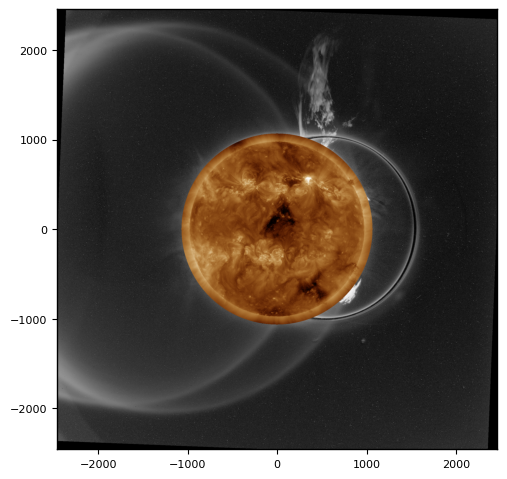

In [34]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88])
ax.imshow(imout, extent=edgout)
plt.show()

### Base-Difference Intensity Composite (SunPy Map)

* **Data Combination:** We combine GOES-R/SUVI 304 Å (solar disk), ASO-S/LST/SCIUV (inner corona), and SOHO/LASCO-C2 (outer corona) across non-overlapping fields of view.
* **Colormaps & Output:** The resulting grayscale matrix retains spatial coordinate metadata and is formatted into a native `sunpy.map.Map` object for standardized solar coordinate plotting.

In [37]:
def suvi304diff(f,fbkg='D:\\solp\\FE20230224\\suvi_full\\suvi304_2023-02-24T192638.fits'):
    m304 = smap.Map(f)
    m304bkg = smap.Map(fbkg)
    im = sct.norm8(m304.data,vmin=0.1,vmax=100,log=True)
    imbkg = sct.norm8(m304bkg.data,vmin=0.1,vmax=100,log=True)
    imd = im.astype(np.int16)-imbkg.astype(np.int16)
    hdr = m304.meta
    hdr['rsun_obs'] = 969.8933149690835
    return smap.Map(imd,hdr)

In [38]:
# difference image of SUVI 304A observation on 2023-02-24
msuvi = suvi304diff('D:\\solp\\FE20230224\\suvi_full\\suvi304_2023-02-24T204819.fits')

In [118]:
fc2b = "D:\\solp\\FE20230224\\lasco\\23925647.fts"
fc2 = "D:\\solp\\FE20230224\\lasco\\23925652.fts"
mc2 = sct.lascoMap(fc2,fbkg=fc2b,despike=True,n_isolate=5)

 [astropy.io.fits.verify]


In [48]:
# SCIUV
fsci = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2048.fits"
fsci_bkg = "D:\\solp\\FE20230224\\sci\\sciuv_long_20230224T2018.fits"
ima, hdra = sct.readfits(fsci)
imb, hdrb = sct.readfits(fsci_bkg)
tmp = sct.norm8(medfilt2d(ima,3),vmin=1,vmax=1500,log=True)
tmp1 = sct.norm8(medfilt2d(imb,3),vmin=1,vmax=1500,log=True)
imd = tmp.astype(np.int16)-tmp1.astype(np.int16)
# use level 1.5 AIA fits file to supply additional information for SCIUV header
faia = "D:\\solp\\FE20230224\\aia15\\AIA_193_2023-02-24T204807.fits"
maia = smap.Map(faia)
hdr = sct.scihdr(hdra, cdelt=2.4, crvals=[0,0], crpixs=[crpix1,crpix2], rotrad=rotrad, aiahdr=maia.fits_header)
msci = sct.scimap(imd, hdr)

In [51]:
imSuviSci,edg = sct.combineDisk_lasco(msuvi, msci, vc2=[-128,128], vdisk=[-128,128], rmask=1.2)
mSuviSci = smap.Map(imSuviSci,msci.meta)

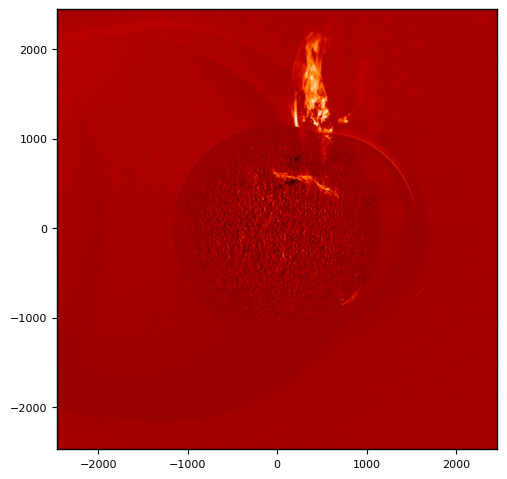

In [52]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88])
ax.imshow(imSuviSci, extent=edg)
plt.show()

In [120]:
imSSC2,edg = sct.combineDisk_lasco(mSuviSci, mc2, vc2=[-1000,1000], vdisk=[0,255], rmask=2)
mssc2 = smap.Map(imSSC2, mc2.meta)

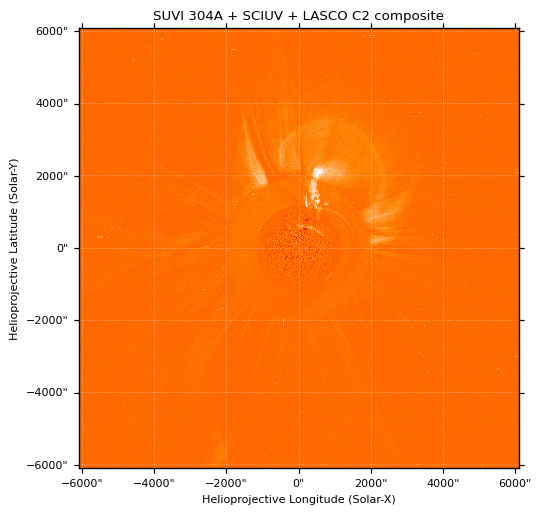

In [124]:
fig = plt.figure(figsize=(5,5))
ax = plt.axes([0.1,0.06,0.88,0.88], projection=mssc2)
mssc2.plot(axes=ax, title='SUVI 304A + SCIUV + LASCO C2 composite', vmin=0, vmax=255)
plt.show()